# Урок 11. Настройка гиперпараметров

**Интерактивная версия:** `lessons/lesson_11/web/index.html`

1. Карта ошибки «темп × число листьев» (её строит `examples/tuning_grid.py`, ≈ 1 минута).
2. Темп и число деревьев: кривые обучения при ν = 0.01, 0.1 и 1.
3. Почему пней мало: парное взаимодействие в задаче Фридмана.

In [1]:
import json

from IPython.display import display
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from gbcourse import datasets
from gbcourse.plotting import use_course_style

use_course_style()

## 1. Карта ошибки

In [2]:
js = (ROOT / "lessons" / "lesson_11" / "web" / "results.js").read_text(encoding="utf-8")
T = json.loads(js[js.index(".tuningGrid = ") + len(".tuningGrid = "): js.rindex(";\n})")])
for key, title in (("val", "RMSE на валидации"), ("trees", "число деревьев")):
    print(title)
    display(pd.DataFrame([[c[key] for c in row] for row in T["grid"]], index=[f"ν={v}" for v in T["lrs"]],
                         columns=[f"{v} л." for v in T["leaves"]]))

RMSE на валидации


,2 л.,4 л.,8 л.,16 л.,32 л.,64 л.,128 л.
ν=0.01,1.7447,1.1510,1.1786,1.2155,1.2413,1.3075,1.4017
ν=0.03,1.7420,1.1382,1.1759,1.2119,1.2440,1.3048,1.4017
ν=0.1,1.7444,1.1365,1.1790,1.2348,1.2723,1.3171,1.4129
ν=0.3,1.7741,1.2031,1.2855,1.3454,1.3862,1.4450,1.5386
ν=1.0,1.8157,1.4652,1.6248,1.9196,2.0144,2.2139,2.3324


число деревьев


,2 л.,4 л.,8 л.,16 л.,32 л.,64 л.,128 л.
ν=0.01,4706,4284,2655,1574,1264,1198,1279
ν=0.03,2285,1792,1055,667,517,588,1154
ν=0.1,763,590,426,226,176,126,196
ν=0.3,274,249,92,62,32,36,41
ν=1.0,241,70,20,9,4,2,2


## 2. Кривые обучения при разном темпе

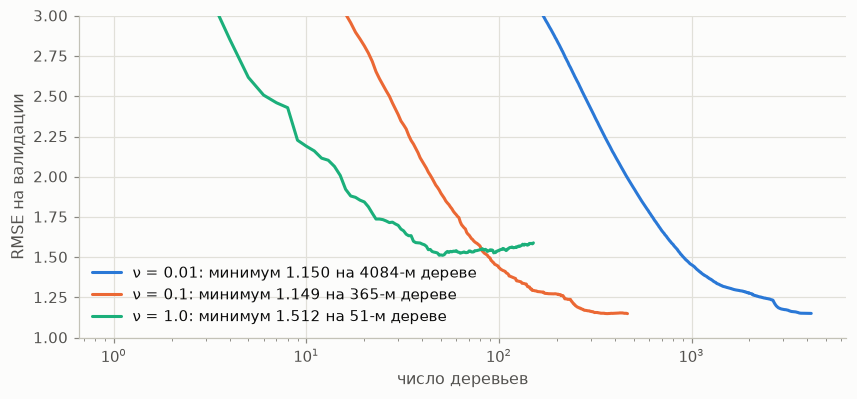

In [3]:
X, y = datasets.friedman1(n=4000, noise=1.0, seed=170)
perm = np.random.default_rng(0).permutation(len(y))
tr, va = perm[:2400], perm[2400:3200]
fig, ax = plt.subplots(figsize=(9, 3.8))
for lr in (0.01, 0.1, 1.0):
    m = lgb.LGBMRegressor(n_estimators=5000, learning_rate=lr, num_leaves=4, min_child_samples=10, verbose=-1)
    m.fit(X[tr], y[tr], eval_X=(X[va],), eval_y=(y[va],), callbacks=[lgb.early_stopping(100, verbose=False)])
    curve = np.sqrt(m.evals_result_["valid_0"]["l2"])
    ax.plot(np.arange(1, len(curve) + 1), curve, label=f"ν = {lr}: минимум {curve.min():.3f} на {int(np.argmin(curve)) + 1}-м дереве")
ax.set(xscale="log", xlabel="число деревьев", ylabel="RMSE на валидации", ylim=(1.0, 3.0))
ax.legend()
plt.show()

## 3. Пни против деревьев с 3–4 листьями

$y = 10\sin(\pi x_0 x_1) + 20(x_2 - 0.5)^2 + 10x_3 + 5x_4 + \varepsilon$. Сумма пней — это сумма функций от отдельных признаков,
она не может выразить $\sin(\pi x_0 x_1)$. Проверим: уберём взаимодействие из $y$, и пни станут не хуже.

In [4]:
inter = 10 * np.sin(np.pi * X[:, 0] * X[:, 1])
y_add = y - inter + 10 * np.sin(np.pi * X[:, 0] / 2) + 10 * np.sin(np.pi * X[:, 1] / 2)  # заменили произведение суммой
rows = []
for name, target in (("исходная задача", y), ("без взаимодействия", y_add)):
    row = {"задача": name}
    for leaves in (2, 4):
        m = lgb.LGBMRegressor(n_estimators=5000, learning_rate=0.1, num_leaves=leaves, min_child_samples=10, verbose=-1)
        m.fit(X[tr], target[tr], eval_X=(X[va],), eval_y=(target[va],), callbacks=[lgb.early_stopping(100, verbose=False)])
        row[f"{leaves} листа"] = np.sqrt(min(m.evals_result_["valid_0"]["l2"]))
    rows.append(row)
pd.DataFrame(rows).round(3)

,задача,2 листа,4 листа
0,исходная задача,1.738,1.149
1,без взаимодействия,1.074,1.156


## Упражнения

1. Постройте такую же карту для задачи «луны + 8 шумовых признаков» (классификация, log-loss). Где лучшая клетка?
2. Для лучшей клетки карты замерьте время обучения при ν = 0.01 и 0.1. Во сколько раз оно отличается?

Решения: `python lessons/lesson_11/exercises/solutions.py`.